# 第 4 章　张量场的微分运算：计算伴侣

本 Notebook 是《张量分析》第 4 章的配套电子资源。它不复制纸质教材的完整理论叙述，而是围绕本章的核心主线建立“**微分定义—符号计算—局部运动学—物理校核—CFD 后处理**”闭环。

本章始终限定在固定的笛卡尔正交基中，并采用教材统一约定

$$
L_{ij}=\partial_jv_i,
$$

以及

$$
(\operatorname{div}\mathbf T)_i
=
\partial_jT_{ij}.
$$

> **代码约定**
>
> - 数学指标 $1,2,3$ 对应 Python 数组下标 `0,1,2`；
> - 张量缩并、散度和运动学分解优先使用显式 `for` 循环；
> - 不使用 `@` 和 `np.einsum`；
> - SymPy 用于符号求导和恒等式验证；
> - NumPy 用于数值数组、线性代数与自检；
> - Matplotlib 用于参数扫描和局部场可视化；
> - 数学公式统一使用 `$...$` 与 `$$...$$`，兼容 Jupyter Book 2 / MyST。

## 学习目标

完成本 Notebook 后，应能够：

1. 对标量场计算梯度、方向导数与物质导数；
2. 按 $L_{ij}=\partial_jv_i$ 自动生成速度梯度，并分解为 $\mathbf D+\mathbf W$；
3. 从速度梯度计算散度、涡量、局部自旋角速度、$Q$ 与黏性耗散率；
4. 按本书约定实现一般二阶张量场的散度；
5. 验证 $\operatorname{div}(-p\mathbf I)=-\nabla p$；
6. 区分 $\partial_jT_{ij}$ 与 $\partial_jT_{ji}$；
7. 计算各向同性与各向异性扩散通量；
8. 分析 Couette–Poiseuille 流中的局部剪切、自旋和耗散；
9. 验证梯度—旋度—散度组成的基本复合微分恒等式；
10. 数值展示拉普拉斯对高波数模态的更强扩散衰减；
11. 验证稳态刚体旋转仍具有非零向心加速度；
12. 解释自由涡旋“局部无旋但环量非零”的局部—整体差别；
13. 建立从 CFD 给定速度梯度 $\mathbf L$ 出发的局部运动学一致性审计流程。

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)

print("NumPy version:", np.__version__)
print("SymPy version:", sp.__version__)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-oizcabsz because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


NumPy version: 2.3.5
SymPy version: 1.14.0


## 1. 基础符号工具

后续计算反复使用固定笛卡尔坐标

$$
(x,y,z)
$$

以及下列分量定义：

$$
(\nabla\phi)_i=\partial_i\phi,
$$

$$
L_{ij}=\partial_jv_i,
$$

$$
\nabla\cdot\mathbf v=\partial_iv_i,
$$

$$
(\nabla\times\mathbf v)_i
=
\varepsilon_{ijk}\partial_jv_k.
$$

In [2]:
x, y, z, t = sp.symbols("x y z t", real=True)
coords = (x, y, z)
coord_matrix = sp.Matrix(coords)


def gradient_scalar(phi):
    return sp.Matrix([
        sp.diff(phi, q)
        for q in coords
    ])


def velocity_gradient(velocity):
    velocity = sp.Matrix(velocity)
    return velocity.jacobian(coord_matrix)


def divergence_vector(velocity):
    velocity = sp.Matrix(velocity)
    result = 0
    for i in range(3):
        result += sp.diff(velocity[i], coords[i])
    return sp.simplify(result)


def curl_vector(velocity):
    velocity = sp.Matrix(velocity)
    return sp.Matrix([
        sp.diff(velocity[2], y) - sp.diff(velocity[1], z),
        sp.diff(velocity[0], z) - sp.diff(velocity[2], x),
        sp.diff(velocity[1], x) - sp.diff(velocity[0], y),
    ])


def vector_laplacian(velocity):
    velocity = sp.Matrix(velocity)
    result = sp.zeros(3, 1)
    for i in range(3):
        for j in range(3):
            result[i] += sp.diff(velocity[i], coords[j], 2)
    return result.applyfunc(sp.simplify)


def double_dot_numeric(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    value = 0.0
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            value += A[i, j] * B[i, j]
    return value


def trace_numeric(A):
    A = np.asarray(A, dtype=float)
    value = 0.0
    for i in range(A.shape[0]):
        value += A[i, i]
    return value


def trace_square_numeric(A):
    A = np.asarray(A, dtype=float)
    value = 0.0
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            value += A[i, j] * A[j, i]
    return value

## 2. 数字赋能 04-A：标量场梯度

对教材中的温度场

$$
T=100-5x^2-3y^2+2xz,
$$

计算

$$
\nabla T
$$

并求点 $(1,2,3)$ 处的梯度。

In [3]:
T = 100 - 5*x**2 - 3*y**2 + 2*x*z
grad_T = gradient_scalar(T)

point = {x: 1, y: 2, z: 3}
grad_T_point = grad_T.subs(point)

print("T =")
sp.pprint(T)
print("\ngrad(T) =")
sp.pprint(grad_T)
print("\ngrad(T) at (1,2,3) =")
sp.pprint(grad_T_point)

expected = sp.Matrix([-4, -12, 2])
assert grad_T_point == expected

T =


     2              2      
- 5⋅x  + 2⋅x⋅z - 3⋅y  + 100

grad(T) =
⎡-10⋅x + 2⋅z⎤
⎢           ⎥
⎢   -6⋅y    ⎥
⎢           ⎥
⎣    2⋅x    ⎦

grad(T) at (1,2,3) =
⎡-4 ⎤
⎢   ⎥
⎢-12⎥
⎢   ⎥
⎣ 2 ⎦


### 方向导数与“最快增加方向”

对任意单位方向 $\mathbf s$，

$$
\frac{\partial T}{\partial s}
=
\mathbf s\cdot\nabla T.
$$

在梯度非零处，最大方向导数等于 $\|\nabla T\|$，并在 $\mathbf s$ 与梯度同向时达到。

In [4]:
grad_numeric = np.array(
    [float(value) for value in grad_T_point],
    dtype=float,
)

s_fast = grad_numeric / np.linalg.norm(grad_numeric)

directional_fast = 0.0
for i in range(3):
    directional_fast += s_fast[i] * grad_numeric[i]

print("unit fastest direction =", s_fast)
print("directional derivative =", directional_fast)
print("||grad T|| =", np.linalg.norm(grad_numeric))

assert np.isclose(
    directional_fast,
    np.linalg.norm(grad_numeric),
)

unit fastest direction = [-0.31234752 -0.93704257  0.15617376]
directional derivative = 12.806248474865699
||grad T|| = 12.806248474865697


## 3. 物质导数：局部变化与平流变化

教材例子取

$$
T(x,y,t)
=
T_0+ax^2-by+ct,
$$

均匀速度

$$
\mathbf v
=
U\mathbf e_1+V\mathbf e_2.
$$

物质导数为

$$
\frac{DT}{Dt}
=
\partial_tT+v_i\partial_iT.
$$

In [5]:
T0, a, b, c, U, V = sp.symbols(
    "T0 a b c U V",
    real=True,
)

T_material = T0 + a*x**2 - b*y + c*t
v_uniform = sp.Matrix([U, V, 0])

grad_material = gradient_scalar(T_material)

advection = 0
for j in range(3):
    advection += v_uniform[j] * grad_material[j]

DTDt = sp.simplify(
    sp.diff(T_material, t) + advection
)

print("local term =", sp.diff(T_material, t))
print("advection term =", sp.simplify(advection))
print("DT/Dt =", DTDt)

assert sp.simplify(
    DTDt - (c + 2*a*U*x - b*V)
) == 0

local term = c
advection term = 2*U*a*x - V*b
DT/Dt = 2*U*a*x - V*b + c


即使 $\partial_tT=0$，只要质点沿速度方向跨越空间温度梯度，仍然可能有

$$
\frac{DT}{Dt}\neq0.
$$

“稳态场”与“运动质点感受到的场量不变”是两个不同陈述。

## 4. 数字赋能 04-B：速度梯度与运动学分解

以二维驻点流

$$
\mathbf v
=
(Ax,-Ay,0)^{\mathsf T}
$$

为例，计算

$$
\mathbf L=\nabla\mathbf v,
\qquad
\mathbf D=\frac12(\mathbf L+\mathbf L^{\mathsf T}),
\qquad
\mathbf W=\frac12(\mathbf L-\mathbf L^{\mathsf T}).
$$

In [6]:
A = sp.symbols("A", real=True)

v_stagnation = sp.Matrix([
    A*x,
    -A*y,
    0,
])

L_stagnation = velocity_gradient(v_stagnation)
D_stagnation = sp.simplify(
    (L_stagnation + L_stagnation.T) / 2
)
W_stagnation = sp.simplify(
    (L_stagnation - L_stagnation.T) / 2
)

print("L =")
sp.pprint(L_stagnation)
print("\nD =")
sp.pprint(D_stagnation)
print("\nW =")
sp.pprint(W_stagnation)

assert W_stagnation == sp.zeros(3)
assert sp.simplify(
    sp.trace(L_stagnation)
) == 0

L =
⎡A  0   0⎤
⎢        ⎥
⎢0  -A  0⎥
⎢        ⎥
⎣0  0   0⎦

D =
⎡A  0   0⎤
⎢        ⎥
⎢0  -A  0⎥
⎢        ⎥
⎣0  0   0⎦

W =
⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦


驻点流满足

$$
\nabla\cdot\mathbf v=0,
\qquad
\mathbf W=\mathbf0,
\qquad
\mathbf D\neq\mathbf0.
$$

因此“无散、无旋”并不等于“无形变”。

## 5. 自动生成速度梯度与运动学分解：对应习题 4.10

构造统一函数，输入三个 SymPy 速度分量，输出

$$
\mathbf L,\quad
\mathbf D,\quad
\mathbf W,\quad
\nabla\cdot\mathbf v,\quad
\nabla\times\mathbf v.
$$

In [7]:
def kinematic_decomposition(velocity):
    velocity = sp.Matrix(velocity)

    L = velocity_gradient(velocity)
    D = sp.simplify((L + L.T) / 2)
    W = sp.simplify((L - L.T) / 2)
    div_v = sp.simplify(sp.trace(L))
    omega = curl_vector(velocity).applyfunc(sp.simplify)

    return L, D, W, div_v, omega


gamma_dot, Omega = sp.symbols(
    "gamma_dot Omega",
    real=True,
)

flows = {
    "stagnation": sp.Matrix([A*x, -A*y, 0]),
    "simple_shear": sp.Matrix([gamma_dot*y, 0, 0]),
    "rigid_rotation": sp.Matrix([-Omega*y, Omega*x, 0]),
}

for name, velocity in flows.items():
    L, D, W, div_v, omega = kinematic_decomposition(velocity)

    print("\n---", name, "---")
    print("div =", div_v)
    print("omega =", list(omega))
    print("D =")
    sp.pprint(D)
    print("W =")
    sp.pprint(W)


--- stagnation ---
div = 0
omega = [0, 0, 0]
D =
⎡A  0   0⎤
⎢        ⎥
⎢0  -A  0⎥
⎢        ⎥
⎣0  0   0⎦
W =
⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦

--- simple_shear ---
div = 0
omega = [0, 0, -gamma_dot]
D =
⎡       γ_dot   ⎤
⎢  0    ─────  0⎥
⎢         2     ⎥
⎢               ⎥
⎢γ_dot          ⎥
⎢─────    0    0⎥
⎢  2            ⎥
⎢               ⎥
⎣  0      0    0⎦
W =
⎡         γ_dot   ⎤
⎢   0     ─────  0⎥
⎢           2     ⎥
⎢                 ⎥
⎢-γ_dot           ⎥
⎢───────    0    0⎥
⎢   2             ⎥
⎢                 ⎥
⎣   0       0    0⎦

--- rigid_rotation ---
div = 0
omega = [0, 0, 2*Omega]
D =
⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦
W =
⎡0  -Ω  0⎤
⎢        ⎥
⎢Ω  0   0⎥
⎢        ⎥
⎣0  0   0⎦


### 从 $\mathbf L$ 直接计算 $Q$

一般定义

$$
Q
=
\frac12
\left[
(\operatorname{tr}\mathbf L)^2
-
\operatorname{tr}(\mathbf L^2)
\right].
$$

只有在不可压缩条件

$$
\operatorname{tr}\mathbf L=0
$$

下，才可写成

$$
Q
=
\frac12
\left(
\|\mathbf W\|_F^2
-
\|\mathbf D\|_F^2
\right).
$$

In [8]:
def analyze_velocity_gradient_numeric(L, mu=None):
    L = np.asarray(L, dtype=float)

    D = np.zeros((3, 3))
    W = np.zeros((3, 3))

    for i in range(3):
        for j in range(3):
            D[i, j] = 0.5 * (L[i, j] + L[j, i])
            W[i, j] = 0.5 * (L[i, j] - L[j, i])

    divergence = trace_numeric(L)

    vorticity = np.array([
        L[2, 1] - L[1, 2],
        L[0, 2] - L[2, 0],
        L[1, 0] - L[0, 1],
    ])

    spin = 0.5 * vorticity

    Q_general = 0.5 * (
        divergence**2
        - trace_square_numeric(L)
    )

    Q_incompressible_form = 0.5 * (
        double_dot_numeric(W, W)
        - double_dot_numeric(D, D)
    )

    Phi = None
    if mu is not None:
        Phi = 2.0 * mu * double_dot_numeric(D, D)

    return {
        "L": L,
        "D": D,
        "W": W,
        "divergence": divergence,
        "vorticity": vorticity,
        "spin": spin,
        "Q_general": Q_general,
        "Q_incompressible_form": Q_incompressible_form,
        "Phi_incompressible_Newtonian": Phi,
    }

In [9]:
Omega_value = 2.0
a_value = 2.0
gamma_value = 2.0

canonical_L = {
    "uniform expansion": np.array([
        [a_value, 0.0, 0.0],
        [0.0, a_value, 0.0],
        [0.0, 0.0, 0.0],
    ]),
    "pure extension": np.array([
        [a_value, 0.0, 0.0],
        [0.0, -a_value, 0.0],
        [0.0, 0.0, 0.0],
    ]),
    "rigid rotation": np.array([
        [0.0, -Omega_value, 0.0],
        [Omega_value, 0.0, 0.0],
        [0.0, 0.0, 0.0],
    ]),
    "simple shear": np.array([
        [0.0, gamma_value, 0.0],
        [0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0],
    ]),
}

for name, L_numeric in canonical_L.items():
    result = analyze_velocity_gradient_numeric(
        L_numeric,
        mu=1.0,
    )

    print(
        f"{name:>18s}: "
        f"div={result['divergence']:+.3f}, "
        f"Q={result['Q_general']:+.3f}, "
        f"Q_inc_expr={result['Q_incompressible_form']:+.3f}, "
        f"Phi={result['Phi_incompressible_Newtonian']:.3f}"
    )

assert np.isclose(
    analyze_velocity_gradient_numeric(
        canonical_L["rigid rotation"]
    )["Q_general"],
    Omega_value**2,
)

assert np.isclose(
    analyze_velocity_gradient_numeric(
        canonical_L["pure extension"]
    )["Q_general"],
    -a_value**2,
)

assert np.isclose(
    analyze_velocity_gradient_numeric(
        canonical_L["simple shear"]
    )["Q_general"],
    0.0,
)

 uniform expansion: div=+4.000, Q=+4.000, Q_inc_expr=-4.000, Phi=16.000
    pure extension: div=+0.000, Q=-4.000, Q_inc_expr=-4.000, Phi=16.000
    rigid rotation: div=+0.000, Q=+4.000, Q_inc_expr=+4.000, Phi=0.000
      simple shear: div=+0.000, Q=+0.000, Q_inc_expr=+0.000, Phi=4.000


均匀膨胀的 $Q$ 也可为正，但它并非不可压缩流动。因此不能把“$Q>0$”脱离不可压缩条件机械解释为“旋转占优”。

## 6. 数字赋能 04-C：矢量散度与张量散度

先复现教材速度场

$$
\mathbf v
=
(3x^2y,\ \sin z-3xy^2,\ 4z+2x^2)^{\mathsf T}.
$$

In [10]:
v_div_example = sp.Matrix([
    3*x**2*y,
    sp.sin(z) - 3*x*y**2,
    4*z + 2*x**2,
])

div_example = divergence_vector(v_div_example)

print("div(v) =", div_example)
assert div_example == 4

div(v) = 4


### 一般二阶张量场的散度

本书采用

$$
(\operatorname{div}\mathbf T)_i
=
\partial_jT_{ij}.
$$

In [11]:
def tensor_divergence(T_field, coordinates=coords):
    T_field = sp.Matrix(T_field)
    result = sp.zeros(3, 1)

    for i in range(3):          # 自由指标 i
        for j in range(3):      # 哑指标 j
            result[i] += sp.diff(
                T_field[i, j],
                coordinates[j],
            )

    return result.applyfunc(sp.simplify)


T_field = sp.Matrix([
    [x**2, x*y, 0],
    [y*z, y**2, x],
    [z, 0, z**2],
])

Div_T = tensor_divergence(T_field)

print("div(T) =")
sp.pprint(Div_T)

div(T) =
⎡3⋅x⎤
⎢   ⎥
⎢2⋅y⎥
⎢   ⎥
⎣2⋅z⎦


## 7. 习题 4.11：压力应力与非对称张量散度

压力应力为

$$
\mathbf T=-p\mathbf I.
$$

应满足

$$
\operatorname{div}(-p\mathbf I)
=
-\nabla p.
$$

In [12]:
p = sp.Function("p")(x, y, z)

pressure_stress = -p * sp.eye(3)
div_pressure_stress = tensor_divergence(
    pressure_stress
)
minus_grad_p = -gradient_scalar(p)

print("div(-p I) =")
sp.pprint(div_pressure_stress)
print("\n-grad(p) =")
sp.pprint(minus_grad_p)

assert sp.simplify(
    div_pressure_stress - minus_grad_p
) == sp.zeros(3, 1)

div(-p I) =
⎡ ∂             ⎤
⎢-──(p(x, y, z))⎥
⎢ ∂x            ⎥
⎢               ⎥
⎢ ∂             ⎥
⎢-──(p(x, y, z))⎥
⎢ ∂y            ⎥
⎢               ⎥
⎢ ∂             ⎥
⎢-──(p(x, y, z))⎥
⎣ ∂z            ⎦

-grad(p) =
⎡ ∂             ⎤
⎢-──(p(x, y, z))⎥
⎢ ∂x            ⎥
⎢               ⎥
⎢ ∂             ⎥
⎢-──(p(x, y, z))⎥
⎢ ∂y            ⎥
⎢               ⎥
⎢ ∂             ⎥
⎢-──(p(x, y, z))⎥
⎣ ∂z            ⎦


对一般非对称张量场，

$$
\partial_jT_{ij}
$$

与

$$
\partial_jT_{ji}
$$

并不相同。

In [13]:
T_nonsym = sp.Matrix([
    [x*y,   x**2,   z],
    [y*z,   y**2,   x*z],
    [x+y,   z**2,   x*z],
])

div_T_standard = tensor_divergence(T_nonsym)
div_T_transpose = tensor_divergence(T_nonsym.T)

print("partial_j T_ij =")
sp.pprint(div_T_standard)
print("\npartial_j T_ji =")
sp.pprint(div_T_transpose)
print("\ndifference =")
sp.pprint(
    sp.simplify(
        div_T_standard - div_T_transpose
    )
)

assert sp.simplify(
    div_T_standard - div_T_transpose
) != sp.zeros(3, 1)

partial_j T_ij =
⎡ y + 1 ⎤
⎢       ⎥
⎢x + 2⋅y⎥
⎢       ⎥
⎣ x + 1 ⎦

partial_j T_ji =
⎡     y + z     ⎤
⎢               ⎥
⎢2⋅x + 2⋅y + 2⋅z⎥
⎢               ⎥
⎣       x       ⎦

difference =
⎡ 1 - z  ⎤
⎢        ⎥
⎢-x - 2⋅z⎥
⎢        ⎥
⎣   1    ⎦


## 8. 旋度、自旋张量与局部角速度

刚体旋转

$$
\mathbf v
=
(-\Omega y,\ \Omega x,\ 0)^{\mathsf T}
$$

应满足

$$
\boldsymbol\omega
=
\nabla\times\mathbf v
=
2\Omega\mathbf e_3,
$$

并且

$$
\boldsymbol\omega_{\mathrm{spin}}
=
\frac12\boldsymbol\omega.
$$

In [14]:
v_rotation = sp.Matrix([
    -Omega*y,
    Omega*x,
    0,
])

L_rot, D_rot, W_rot, div_rot, omega_rot = (
    kinematic_decomposition(v_rotation)
)

spin_rot = sp.simplify(omega_rot / 2)

print("L =")
sp.pprint(L_rot)
print("\nD =")
sp.pprint(D_rot)
print("\nW =")
sp.pprint(W_rot)
print("\nomega =")
sp.pprint(omega_rot)
print("\nspin =")
sp.pprint(spin_rot)

assert D_rot == sp.zeros(3)
assert div_rot == 0
assert omega_rot == sp.Matrix([0, 0, 2*Omega])
assert spin_rot == sp.Matrix([0, 0, Omega])

L =
⎡0  -Ω  0⎤
⎢        ⎥
⎢Ω  0   0⎥
⎢        ⎥
⎣0  0   0⎦

D =
⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦

W =
⎡0  -Ω  0⎤
⎢        ⎥
⎢Ω  0   0⎥
⎢        ⎥
⎣0  0   0⎦

omega =
⎡ 0 ⎤
⎢   ⎥
⎢ 0 ⎥
⎢   ⎥
⎣2⋅Ω⎦

spin =
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣Ω⎦


### 简单剪切同时包含变形与自旋

$$
v_1=\dot\gamma y,
\qquad
v_2=v_3=0.
$$

它具有非零 $\mathbf D$ 和 $\mathbf W$，但

$$
Q=0.
$$

In [15]:
v_shear = sp.Matrix([
    gamma_dot*y,
    0,
    0,
])

L_shear, D_shear, W_shear, div_shear, omega_shear = (
    kinematic_decomposition(v_shear)
)

print("D =")
sp.pprint(D_shear)
print("\nW =")
sp.pprint(W_shear)
print("\nomega =")
sp.pprint(omega_shear)

assert div_shear == 0
assert omega_shear == sp.Matrix([0, 0, -gamma_dot])
assert D_shear != sp.zeros(3)
assert W_shear != sp.zeros(3)

D =
⎡       γ_dot   ⎤
⎢  0    ─────  0⎥
⎢         2     ⎥
⎢               ⎥
⎢γ_dot          ⎥
⎢─────    0    0⎥
⎢  2            ⎥
⎢               ⎥
⎣  0      0    0⎦

W =
⎡         γ_dot   ⎤
⎢   0     ─────  0⎥
⎢           2     ⎥
⎢                 ⎥
⎢-γ_dot           ⎥
⎢───────    0    0⎥
⎢   2             ⎥
⎢                 ⎥
⎣   0       0    0⎦

omega =
⎡  0   ⎤
⎢      ⎥
⎢  0   ⎥
⎢      ⎥
⎣-γ_dot⎦


## 9. 工程题 4.7：轴向膨胀与刚体旋转叠加

考虑

$$
\mathbf v
=
(-Ax_2,\ Ax_1,\ Bx_3)^{\mathsf T}.
$$

其中 $A$ 控制绕 $x_3$ 轴的刚体式旋转，$B$ 控制 $x_3$ 方向伸缩。

In [16]:
Arot, Bexp = sp.symbols(
    "Arot Bexp",
    real=True,
)

v_mixed = sp.Matrix([
    -Arot*y,
    Arot*x,
    Bexp*z,
])

L_mixed, D_mixed, W_mixed, div_mixed, omega_mixed = (
    kinematic_decomposition(v_mixed)
)

print("L =")
sp.pprint(L_mixed)
print("\nD =")
sp.pprint(D_mixed)
print("\nW =")
sp.pprint(W_mixed)
print("\ndiv =", div_mixed)
print("omega =", list(omega_mixed))

assert div_mixed == Bexp
assert omega_mixed == sp.Matrix([0, 0, 2*Arot])

L =
⎡ 0    -Arot   0  ⎤
⎢                 ⎥
⎢Arot    0     0  ⎥
⎢                 ⎥
⎣ 0      0    Bexp⎦

D =
⎡0  0   0  ⎤
⎢          ⎥
⎢0  0   0  ⎥
⎢          ⎥
⎣0  0  Bexp⎦

W =
⎡ 0    -Arot  0⎤
⎢              ⎥
⎢Arot    0    0⎥
⎢              ⎥
⎣ 0      0    0⎦

div = Bexp
omega = [0, 0, 2*Arot]


不可压缩条件为

$$
B=0.
$$

此时只剩绕 $x_3$ 轴的局部刚体式旋转。

## 10. 工程题 4.8：各向同性与各向异性扩散通量

温度场

$$
T(x,y)
=
T_0+x^2+4y^2.
$$

在 $(1,1)$ 处

$$
\nabla T=(2,8)^{\mathsf T}.
$$

In [17]:
T0_symbol, k = sp.symbols(
    "T0_symbol k",
    real=True,
    positive=True,
)

T_2d = T0_symbol + x**2 + 4*y**2
grad_T_2d = sp.Matrix([
    sp.diff(T_2d, x),
    sp.diff(T_2d, y),
])

grad_at_11 = grad_T_2d.subs({
    x: 1,
    y: 1,
})

q_iso = -k * grad_at_11

K_aniso = sp.Matrix([
    [4*k, k],
    [k, 2*k],
])

q_aniso = -K_aniso * grad_at_11
q_dot_grad = sp.expand(
    q_aniso.dot(grad_at_11)
)

print("grad(T) at (1,1) =")
sp.pprint(grad_at_11)
print("\nisotropic q =")
sp.pprint(q_iso)
print("\nanisotropic q =")
sp.pprint(q_aniso)
print("\nq_aniso · grad(T) =", q_dot_grad)

assert grad_at_11 == sp.Matrix([2, 8])
assert q_aniso == sp.Matrix([-16*k, -18*k])
assert sp.simplify(
    q_dot_grad + 176*k
) == 0

grad(T) at (1,1) =
⎡2⎤
⎢ ⎥
⎣8⎦

isotropic q =
⎡-2⋅k⎤
⎢    ⎥
⎣-8⋅k⎦

anisotropic q =
⎡-16⋅k⎤
⎢     ⎥
⎣-18⋅k⎦

q_aniso · grad(T) = -176*k


各向异性热流一般不与 $-\nabla T$ 共线，但当 $\mathbf K$ 对称正定时仍有

$$
\mathbf q\cdot\nabla T<0
$$

（梯度非零时），表示热流具有沿温度降低方向的分量。

## 11. 工程题 4.9：Couette–Poiseuille 流的局部运动学

速度场

$$
\mathbf v=u(y)\mathbf e_1,
$$

其中

$$
u(y)
=
\frac{U}{H}y
+
\frac{G}{2\mu}y(H-y).
$$

其局部剪切率为

$$
\frac{du}{dy}
=
\frac{U}{H}
+
\frac{G}{2\mu}(H-2y).
$$

In [18]:
Ucp, Hcp, Gcp, mucp = sp.symbols(
    "Ucp Hcp Gcp mucp",
    real=True,
    nonzero=True,
)

u_cp = (
    Ucp/Hcp * y
    + Gcp/(2*mucp) * y * (Hcp - y)
)

v_cp = sp.Matrix([u_cp, 0, 0])

L_cp, D_cp, W_cp, div_cp, omega_cp = (
    kinematic_decomposition(v_cp)
)

shear_rate_cp = sp.simplify(
    sp.diff(u_cp, y)
)

tau12_cp = sp.simplify(
    2*mucp * D_cp[0, 1]
)

Phi_cp = sp.simplify(
    2*mucp * sum(
        D_cp[i, j]**2
        for i in range(3)
        for j in range(3)
    )
)

y_zero_shear = sp.solve(
    sp.Eq(shear_rate_cp, 0),
    y,
)

print("du/dy =")
sp.pprint(shear_rate_cp)
print("\ntau_12 =")
sp.pprint(tau12_cp)
print("\nPhi =")
sp.pprint(Phi_cp)
print("\ny at zero shear =", y_zero_shear)

assert div_cp == 0
assert sp.simplify(
    tau12_cp - mucp*shear_rate_cp
) == 0
assert sp.simplify(
    Phi_cp - mucp*shear_rate_cp**2
) == 0

du/dy =
Gcp⋅Hcp   Gcp⋅y   Ucp
─────── - ───── + ───
2⋅mucp    mucp    Hcp

tau_12 =
Gcp⋅Hcp           Ucp⋅mucp
─────── - Gcp⋅y + ────────
   2                Hcp   

Phi =
                                  2
(Gcp⋅Hcp⋅(Hcp - 2⋅y) + 2⋅Ucp⋅mucp) 
───────────────────────────────────
                 2                 
            4⋅Hcp ⋅mucp            

y at zero shear = [Hcp/2 + Ucp*mucp/(Gcp*Hcp)]


### 参数扫描：剪切、自旋和耗散沿通道高度的变化

取一组无量纲示例

$$
U=1,\qquad
H=1,\qquad
G=4,\qquad
\mu=1.
$$

此时零剪切位置位于 $y/H=0.75$。

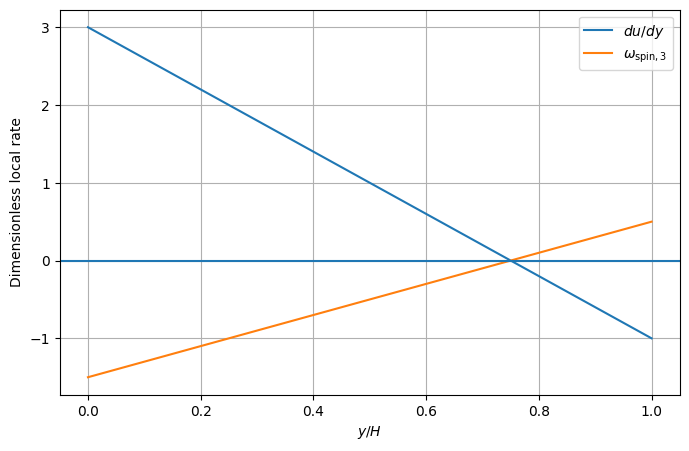

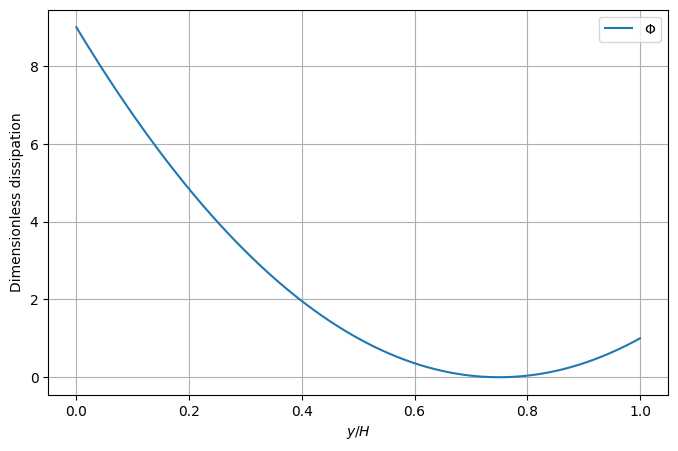

zero-shear location y/H = 0.75


In [19]:
U_num = 1.0
H_num = 1.0
G_num = 4.0
mu_num = 1.0

y_values = np.linspace(0.0, H_num, 300)

shear_values = (
    U_num/H_num
    + G_num/(2.0*mu_num)
    * (H_num - 2.0*y_values)
)

vorticity_values = -shear_values
spin_values = 0.5 * vorticity_values
Phi_values = mu_num * shear_values**2

zero_location = (
    H_num/2.0
    + mu_num*U_num/(G_num*H_num)
)

plt.figure(figsize=(8, 5))
plt.plot(
    y_values/H_num,
    shear_values,
    label=r"$du/dy$",
)
plt.plot(
    y_values/H_num,
    spin_values,
    label=r"$\omega_{\mathrm{spin},3}$",
)
plt.axhline(0.0)
plt.xlabel(r"$y/H$")
plt.ylabel("Dimensionless local rate")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    y_values/H_num,
    Phi_values,
    label=r"$\Phi$",
)
plt.xlabel(r"$y/H$")
plt.ylabel("Dimensionless dissipation")
plt.grid(True)
plt.legend()
plt.show()

print("zero-shear location y/H =", zero_location/H_num)

assert np.isclose(zero_location/H_num, 0.75)
assert np.isclose(
    np.interp(
        zero_location,
        y_values,
        Phi_values,
    ),
    0.0,
    atol=5e-4,
)

在零剪切位置，

$$
\frac{du}{dy}=0,
$$

因此局部涡量、自旋和不可压缩牛顿流体黏性耗散率都同时为零。

## 12. 拉普拉斯与扩散模态衰减

对一维模态

$$
\phi(x)=\sin(kx),
$$

有

$$
\nabla^2\phi=-k^2\phi.
$$

若满足扩散方程

$$
\partial_t\phi
=
\kappa\nabla^2\phi,
$$

则振幅按

$$
e^{-\kappa k^2t}
$$

衰减。高波数、小尺度结构衰减更快。

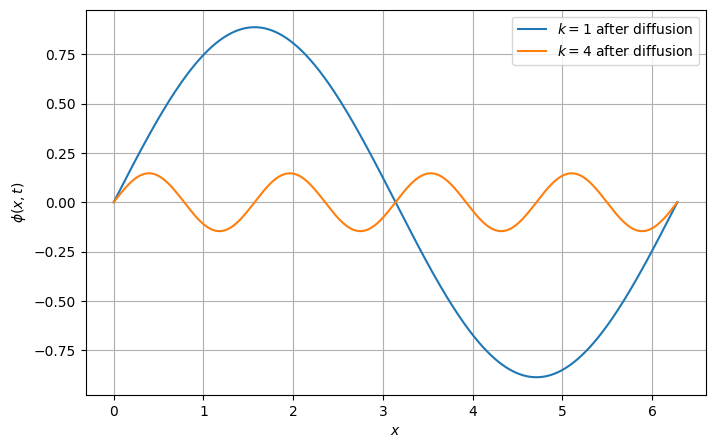

amplitude factor k=1: 0.8869204367171575
amplitude factor k=4: 0.14660696213035015


In [20]:
x_plot = np.linspace(0.0, 2.0*np.pi, 600)

kappa = 0.08
time_value = 1.5

k_low = 1.0
k_high = 4.0

phi_low_initial = np.sin(k_low*x_plot)
phi_high_initial = np.sin(k_high*x_plot)

phi_low_final = (
    np.exp(-kappa*k_low**2*time_value)
    * phi_low_initial
)

phi_high_final = (
    np.exp(-kappa*k_high**2*time_value)
    * phi_high_initial
)

plt.figure(figsize=(8, 5))
plt.plot(
    x_plot,
    phi_low_final,
    label=r"$k=1$ after diffusion",
)
plt.plot(
    x_plot,
    phi_high_final,
    label=r"$k=4$ after diffusion",
)
plt.xlabel(r"$x$")
plt.ylabel(r"$\phi(x,t)$")
plt.grid(True)
plt.legend()
plt.show()

amp_low = np.exp(
    -kappa*k_low**2*time_value
)
amp_high = np.exp(
    -kappa*k_high**2*time_value
)

print("amplitude factor k=1:", amp_low)
print("amplitude factor k=4:", amp_high)

assert amp_high < amp_low

## 13. 变物性系数：为什么不能机械移出微分算子？

### 13.1 变导热系数

$$
\nabla\cdot(k\nabla T)
=
\nabla k\cdot\nabla T
+
k\nabla^2T.
$$

In [21]:
k_field = sp.Function("k")(x, y, z)
T_field = sp.Function("T")(x, y, z)

grad_k = gradient_scalar(k_field)
grad_T_field = gradient_scalar(T_field)

lhs_conduction = 0
for i in range(3):
    lhs_conduction += sp.diff(
        k_field * grad_T_field[i],
        coords[i],
    )

gradk_dot_gradT = 0
for i in range(3):
    gradk_dot_gradT += (
        grad_k[i] * grad_T_field[i]
    )

lap_T = 0
for i in range(3):
    lap_T += sp.diff(
        T_field,
        coords[i],
        2,
    )

rhs_conduction = (
    gradk_dot_gradT
    + k_field * lap_T
)

residual_conduction = sp.simplify(
    lhs_conduction - rhs_conduction
)

print("residual =", residual_conduction)
assert residual_conduction == 0

residual = 0


只有当 $k$ 为空间常数时，$\nabla k=\mathbf0$，才能进一步简化。

### 13.2 变黏度不可压缩牛顿流体

教材给出

$$
\tau_{ij}
=
\mu(\mathbf x)
(\partial_jv_i+\partial_iv_j).
$$

即使满足不可压缩条件，若 $\mu$ 随空间变化，黏性力仍包含黏度梯度项，不能直接写成

$$
\mu\nabla^2\mathbf v.
$$

## 14. 习题 4.12：复合微分恒等式的符号验证

下面使用抽象函数分量验证三个基本恒等式。SymPy 能够把足够光滑抽象函数的混合偏导视为可交换，因此这种验证隐含了经典二阶可微条件。

In [22]:
phi = sp.Function("phi")(x, y, z)

v1 = sp.Function("v1")(x, y, z)
v2 = sp.Function("v2")(x, y, z)
v3 = sp.Function("v3")(x, y, z)
v_abstract = sp.Matrix([v1, v2, v3])

curl_grad_phi = curl_vector(
    gradient_scalar(phi)
).applyfunc(sp.simplify)

div_curl_v = sp.simplify(
    divergence_vector(
        curl_vector(v_abstract)
    )
)

curl_curl_v = curl_vector(
    curl_vector(v_abstract)
).applyfunc(sp.simplify)

grad_div_v = gradient_scalar(
    divergence_vector(v_abstract)
)

lap_v = vector_laplacian(
    v_abstract
)

double_curl_residual = (
    curl_curl_v
    - grad_div_v
    + lap_v
).applyfunc(sp.simplify)

print("curl(grad(phi)) =")
sp.pprint(curl_grad_phi)
print("\ndiv(curl(v)) =", div_curl_v)
print("\ndouble-curl residual =")
sp.pprint(double_curl_residual)

assert curl_grad_phi == sp.zeros(3, 1)
assert div_curl_v == 0
assert double_curl_residual == sp.zeros(3, 1)

curl(grad(phi)) =


⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

div(curl(v)) = 0

double-curl residual =
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦


若场含有奇点、间断或分布源，经典偏导的交换和上述点态恒等式需要重新审查，不能机械套用。

## 15. 对流加速度恒等式与稳态向心加速度

稳态刚体旋转

$$
\mathbf v
=
(-\Omega y,\ \Omega x,\ 0)^{\mathsf T}
$$

虽然满足

$$
\partial_t\mathbf v=\mathbf0,
$$

但对流加速度不为零。

In [23]:
L_rotation = velocity_gradient(
    v_rotation
)

convective = sp.zeros(3, 1)

# a_i^(conv) = L_ij v_j
for i in range(3):
    for j in range(3):
        convective[i] += (
            L_rotation[i, j]
            * v_rotation[j]
        )

convective = convective.applyfunc(
    sp.simplify
)

expected_centripetal = sp.Matrix([
    -Omega**2*x,
    -Omega**2*y,
    0,
])

print("convective acceleration =")
sp.pprint(convective)

assert sp.simplify(
    convective - expected_centripetal
) == sp.zeros(3, 1)

convective acceleration =
⎡  2  ⎤
⎢-Ω ⋅x⎥
⎢     ⎥
⎢  2  ⎥
⎢-Ω ⋅y⎥
⎢     ⎥
⎣  0  ⎦


再用恒等式

$$
(\mathbf v\cdot\nabla)\mathbf v
=
\nabla\left(
\frac12\mathbf v\cdot\mathbf v
\right)
-
\mathbf v\times
(\nabla\times\mathbf v)
$$

独立核对。

In [24]:
speed_sq = sp.expand(
    sum(
        v_rotation[i]**2
        for i in range(3)
    )
)

grad_kinetic = gradient_scalar(
    sp.Rational(1, 2) * speed_sq
)

omega_rotation = curl_vector(
    v_rotation
)

v_cross_omega = sp.Matrix([
    v_rotation[1]*omega_rotation[2]
    - v_rotation[2]*omega_rotation[1],

    v_rotation[2]*omega_rotation[0]
    - v_rotation[0]*omega_rotation[2],

    v_rotation[0]*omega_rotation[1]
    - v_rotation[1]*omega_rotation[0],
])

identity_rhs = (
    grad_kinetic - v_cross_omega
).applyfunc(sp.simplify)

print("identity RHS =")
sp.pprint(identity_rhs)

assert sp.simplify(
    identity_rhs - convective
) == sp.zeros(3, 1)

identity RHS =
⎡  2  ⎤
⎢-Ω ⋅x⎥
⎢     ⎥
⎢  2  ⎥
⎢-Ω ⋅y⎥
⎢     ⎥
⎣  0  ⎦


## 16. 习题 4.13：自由涡旋的局部与整体性质

考虑

$$
\mathbf v
=
\frac{\Gamma}
{2\pi(x^2+y^2)}
(-y,\ x,\ 0)^{\mathsf T}.
$$

在原点之外，局部散度和局部旋度均为零。

In [25]:
Gamma = sp.symbols(
    "Gamma",
    real=True,
)

r2 = x**2 + y**2

v_vortex = sp.Matrix([
    -Gamma*y/(2*sp.pi*r2),
    Gamma*x/(2*sp.pi*r2),
    0,
])

div_vortex = sp.simplify(
    divergence_vector(v_vortex)
)

curl_vortex = curl_vector(
    v_vortex
).applyfunc(sp.simplify)

print("div(vortex) =", div_vortex)
print("curl(vortex) =")
sp.pprint(curl_vortex)

assert div_vortex == 0
assert curl_vortex == sp.zeros(3, 1)

div(vortex) = 0
curl(vortex) =
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦


### 圆周环量

沿半径为 $R$ 的圆

$$
x=R\cos\theta,
\qquad
y=R\sin\theta,
$$

计算

$$
\oint\mathbf v\cdot d\mathbf r.
$$

In [26]:
theta_symbol = sp.symbols(
    "theta_symbol",
    real=True,
)

R = sp.symbols(
    "R",
    real=True,
    positive=True,
)

x_circle = R*sp.cos(theta_symbol)
y_circle = R*sp.sin(theta_symbol)

dx_dtheta = sp.diff(
    x_circle,
    theta_symbol,
)
dy_dtheta = sp.diff(
    y_circle,
    theta_symbol,
)

v1_circle = sp.simplify(
    v_vortex[0].subs({
        x: x_circle,
        y: y_circle,
    })
)

v2_circle = sp.simplify(
    v_vortex[1].subs({
        x: x_circle,
        y: y_circle,
    })
)

integrand = sp.simplify(
    v1_circle*dx_dtheta
    + v2_circle*dy_dtheta
)

circulation = sp.simplify(
    sp.integrate(
        integrand,
        (theta_symbol, 0, 2*sp.pi),
    )
)

print("integrand =", integrand)
print("circulation =", circulation)

assert sp.simplify(
    circulation - Gamma
) == 0

integrand = Gamma/(2*pi)
circulation = Gamma


因此在穿孔区域中可以同时出现

$$
\nabla\times\mathbf v=\mathbf0
$$

和

$$
\oint\mathbf v\cdot d\mathbf r=\Gamma\neq0.
$$

这正是“局部无旋”不能自动推出“整个非单连通区域存在全局单值速度势”的典型例子。

## 17. 习题 4.14：常见简化公式的适用条件审计

下面把教材中的五个常见误用整理成计算伴侣中的“条件卡”。

| 简化写法 | 不能省略的关键条件 |
|---|---|
| $\nabla\cdot(k\nabla T)=k\nabla^2T$ | $k$ 为空间常数 |
| $\operatorname{div}\boldsymbol\tau=\mu\nabla^2\mathbf v$ | 牛顿流体、恒 $\mu$；教材所用简式还要求不可压缩 |
| $Q=\tfrac12(\|\mathbf W\|_F^2-\|\mathbf D\|_F^2)$ | $\nabla\cdot\mathbf v=0$ |
| $\nabla\times\mathbf v=\mathbf0\Rightarrow\mathbf v=\nabla\Phi$ 且全局单值 | 足够光滑且定义域满足合适拓扑条件，典型充分条件是单连通 |
| $\nabla\cdot\mathbf v=0\Rightarrow\rho$ 全场同一常数 | 只能推出 $D\rho/Dt=0$；还需初始/边界条件才能进一步得到空间统一常密度 |

这五类条件分别涉及物性系数、运动学约束、拓扑条件和初始/边界条件，不能混为同一种“公式前提”。

## 18. 习题 4.15：CFD 局部运动学一致性审计

设 CFD 后处理程序直接给出某一点的速度梯度

$$
\mathbf L.
$$

从 $\mathbf L$ 可以直接得到：

$$
\nabla\cdot\mathbf v=\operatorname{tr}\mathbf L,
$$

$$
\mathbf D=\frac12(\mathbf L+\mathbf L^{\mathsf T}),
$$

$$
\mathbf W=\frac12(\mathbf L-\mathbf L^{\mathsf T}),
$$

以及涡量、$Q$ 等局部量。

下面封装一个适合后处理的审计函数。

In [27]:
def cfd_kinematic_audit(L, mu=None):
    result = analyze_velocity_gradient_numeric(
        L,
        mu=mu,
    )

    result["decomposition_error"] = np.linalg.norm(
        result["L"]
        - result["D"]
        - result["W"]
    )

    result["D_symmetry_error"] = np.linalg.norm(
        result["D"] - result["D"].T
    )

    result["W_skew_error"] = np.linalg.norm(
        result["W"] + result["W"].T
    )

    result["incompressibility_residual"] = abs(
        result["divergence"]
    )

    return result


L_cfd = np.array([
    [ 0.02,  5.00, -0.10],
    [-4.60, -0.01,  0.20],
    [ 0.05, -0.15, -0.01],
])

audit = cfd_kinematic_audit(
    L_cfd,
    mu=1.8e-5,
)

for key in [
    "divergence",
    "vorticity",
    "spin",
    "Q_general",
    "Q_incompressible_form",
    "Phi_incompressible_Newtonian",
    "decomposition_error",
    "D_symmetry_error",
    "W_skew_error",
]:
    print(key, "=", audit[key])

assert audit["decomposition_error"] < 1e-12
assert audit["D_symmetry_error"] < 1e-12
assert audit["W_skew_error"] < 1e-12

divergence = 0.0
vorticity = [-0.35 -0.15 -9.6 ]
spin = [-0.175 -0.075 -4.8  ]
Q_general = 23.034699999999997
Q_incompressible_form = 23.034699999999997
Phi_incompressible_Newtonian = 2.9916000000000054e-06
decomposition_error = 0.0
D_symmetry_error = 0.0
W_skew_error = 0.0


### 如何解释审计结果？

必须把三层问题区分开：

1. **数学定义：** $\mathbf D,\mathbf W,\boldsymbol\omega,Q$ 可以由 $\mathbf L$ 的分量直接计算；
2. **物理解释：** 把 $Q>0$ 解释为“旋转占优”通常建立在不可压缩条件下；把
   $$
   \Phi=2\mu\mathbf D:\mathbf D
   $$
   用作黏性耗散率还需要不可压缩牛顿流体与 $\mu>0$ 等假设；
3. **数值离散：** 若求解器满足离散连续性方程，但后处理插值后的 $\nabla\cdot\mathbf v$ 不严格为零，应进一步区分离散误差、梯度重构误差、插值误差和真实物理可压缩性。

非零涡量只说明速度梯度含有反对称信息，不能单独证明存在相干涡结构。

## 19. 一个可视化的 $Q$ 竞争实验

考虑二维不可压缩线性流

$$
\mathbf v
=
(a x-\Omega y,\ \Omega x-a y)^{\mathsf T}.
$$

这里

- $a$ 控制纯拉伸；
- $\Omega$ 控制刚体式旋转。

其

$$
Q=\Omega^2-a^2.
$$

因此：

- $|\Omega|>|a|$：$Q>0$；
- $|\Omega|<|a|$：$Q<0$；
- $|\Omega|=|a|$：$Q=0$。

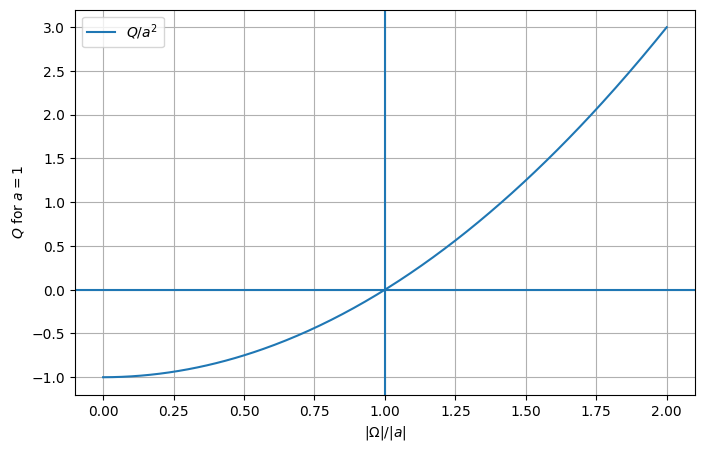

In [28]:
ratio = np.linspace(
    0.0,
    2.0,
    300,
)

a_reference = 1.0
Omega_values = ratio * a_reference

Q_values = (
    Omega_values**2
    - a_reference**2
)

plt.figure(figsize=(8, 5))
plt.plot(
    ratio,
    Q_values,
    label=r"$Q/a^2$",
)
plt.axhline(0.0)
plt.axvline(1.0)
plt.xlabel(r"$|\Omega|/|a|$")
plt.ylabel(r"$Q$ for $a=1$")
plt.grid(True)
plt.legend()
plt.show()

assert np.isclose(
    Q_values[
        np.argmin(
            np.abs(ratio - 1.0)
        )
    ],
    0.0,
    atol=2e-2,
)

这个实验展示了 $Q$ 准则真正比较的是速度梯度中“局部旋转”和“局部变形”的相对强弱，而不是单独检测涡量是否非零。

## 20. 本章计算关系总表

物质导数：

$$
\boxed{
\frac{D}{Dt}
=
\frac{\partial}{\partial t}
+
\mathbf v\cdot\nabla
}
$$

矢量梯度：

$$
\boxed{
L_{ij}
=
\partial_jv_i
}
$$

速度梯度分解：

$$
\boxed{
\mathbf L
=
\mathbf D+\mathbf W
}
$$

散度：

$$
\boxed{
\nabla\cdot\mathbf v
=
\partial_iv_i
=
\operatorname{tr}\mathbf L
}
$$

张量散度：

$$
\boxed{
(\operatorname{div}\mathbf T)_i
=
\partial_jT_{ij}
}
$$

旋度：

$$
\boxed{
\omega_i
=
(\nabla\times\mathbf v)_i
=
\varepsilon_{ijk}\partial_jv_k
}
$$

自旋与涡量：

$$
\boxed{
W_{ij}
=
-\frac12
\varepsilon_{ijk}\omega_k
}
$$

$$
\boxed{
\boldsymbol\omega_{\mathrm{spin}}
=
\frac12\boldsymbol\omega
}
$$

速度梯度第二不变量：

$$
\boxed{
Q
=
\frac12
\left[
(\operatorname{tr}\mathbf L)^2
-
\operatorname{tr}(\mathbf L^2)
\right]
}
$$

不可压缩形式：

$$
\boxed{
Q
=
\frac12
\left(
\|\mathbf W\|_F^2
-
\|\mathbf D\|_F^2
\right)
}
$$

不可压缩牛顿流体黏性耗散：

$$
\boxed{
\Phi
=
2\mu\mathbf D:\mathbf D
}
$$

双重旋度恒等式：

$$
\boxed{
\nabla\times(\nabla\times\mathbf v)
=
\nabla(\nabla\cdot\mathbf v)
-
\nabla^2\mathbf v
}
$$

对流加速度恒等式：

$$
\boxed{
(\mathbf v\cdot\nabla)\mathbf v
=
\nabla\left(
\frac12\mathbf v\cdot\mathbf v
\right)
-
\mathbf v\times
(\nabla\times\mathbf v)
}
$$

### 本章最重要的计算习惯

- 先明确微分算子的**作用对象和作用范围**；
- 始终保持本书约定 $L_{ij}=\partial_jv_i$；
- 张量散度统一使用 $\partial_jT_{ij}$；
- 先算一般形式，再根据不可压缩、恒物性等条件简化；
- 区分涡量、局部自旋角速度、$Q$ 与黏性耗散；
- 对自由涡旋等含奇点问题，同时检查局部微分性质和全局积分/拓扑性质；
- CFD 后处理时，把“数学定义、连续物理模型、离散误差”分开审计。